In [6]:
# =========================================================
# Install PyTorch Geometric
# =========================================================

!pip install torch-geometric pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

# =========================================================
# Imports
# =========================================================

import os
import json
import torch
import random
import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================================================
# GPU Configuration
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

# =========================================================
# Check Kaggle Input Files
# =========================================================

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# =========================================================
# Base Path
# =========================================================

BASE_PATH = "/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/"

# =========================================================
# Configuration
# =========================================================

seeds = [42, 123, 2023]

window_size = 10
learning_rate = 0.001

hidden_sizes = [64, 128]
epoch_options = [300, 500]

years = range(2000, 2024)

num_nodes = 5040

# =========================================================
# Utility Function
# =========================================================

def create_sequences(data, window):

    X, y = [], []

    for i in range(len(data) - window):

        X.append(data[i:i+window])
        y.append(data[i+window])

    return torch.stack(X), torch.stack(y)

# =========================================================
# GLOBAL NORMALIZATION
# (Training Years Only)
# =========================================================

all_years_data = []

for year in years:

    yearly_data = torch.load(
        BASE_PATH + f"node_features_{year}.pt"
    )

    yearly_data = torch.nan_to_num(yearly_data)

    all_years_data.append(yearly_data)

all_years_data = torch.stack(all_years_data)

print("All years data shape:", all_years_data.shape)

train_years = int(0.8 * len(years))

train_data = all_years_data[:train_years]

global_mean = train_data.mean(dim=(0,1))
global_std  = train_data.std(dim=(0,1)) + 1e-6

print("Global Mean:", global_mean)
print("Global Std :", global_std)

# =========================================================
# Load RAW Features
# =========================================================

raw_years = []

for year in years:

    raw = torch.load(
        BASE_PATH + f"node_features_{year}.pt"
    )

    raw = torch.nan_to_num(raw)

    raw = (raw - global_mean) / global_std

    raw_years.append(raw.flatten())

X_raw = torch.stack(raw_years)

print("Raw input shape:", X_raw.shape)

X_raw = X_raw.to(device)

# =========================================================
# Load Spatial Embeddings
# =========================================================

embeddings = []

for year in years:

    emb = torch.load(
        BASE_PATH + f"spatial_embeddings_{year}.pt"
    )

    emb = torch.nan_to_num(emb)

    embeddings.append(emb.flatten())

X_spatial = torch.stack(embeddings)

print("Spatial input shape:", X_spatial.shape)

X_spatial = X_spatial.to(device)

# =========================================================
# Define Models
# =========================================================

class LSTMModel(torch.nn.Module):

    def __init__(self, input_size, hidden_size):

        super().__init__()

        self.lstm = torch.nn.LSTM(
            input_size,
            hidden_size,
            batch_first=True
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            input_size
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        return self.fc(out[:, -1, :])


class GRUModel(torch.nn.Module):

    def __init__(self, input_size, hidden_size):

        super().__init__()

        self.gru = torch.nn.GRU(
            input_size,
            hidden_size,
            batch_first=True
        )

        self.fc = torch.nn.Linear(
            hidden_size,
            input_size
        )

    def forward(self, x):

        out, _ = self.gru(x)

        return self.fc(out[:, -1, :])

# =========================================================
# Model Dictionary
# =========================================================

models_dict = {
    "LSTM (Raw)":   (X_raw, LSTMModel),
    "GRU (Raw)":    (X_raw, GRUModel),
    "GATv2-LSTM":   (X_spatial, LSTMModel),
    "GATv2-GRU":    (X_spatial, GRUModel)
}

# =========================================================
# Hyperparameter Tuning
# =========================================================

best_results = {}

for model_name, (data_used, model_class) in models_dict.items():

    print("\n===================================")
    print(f"Tuning {model_name}")
    print("===================================")

    best_r2 = -1e9
    best_config = None

    for hidden_size in hidden_sizes:

        for epochs in epoch_options:

            print(
                f"\nConfig: "
                f"hidden_size={hidden_size}, "
                f"epochs={epochs}"
            )

            # ---------------------------------------------
            # Create Sequences
            # ---------------------------------------------

            X, y = create_sequences(
                data_used,
                window_size
            )

            X = X.to(device)
            y = y.to(device)

            split = int(0.8 * len(X))

            X_train, X_test = X[:split], X[split:]
            y_train, y_test = y[:split], y[split:]

            rmse_list = []
            mae_list  = []
            r2_list   = []

            # ---------------------------------------------
            # Rainfall Metrics
            # ---------------------------------------------

            rmse_rain_list = []
            mae_rain_list  = []
            r2_rain_list   = []

            # ---------------------------------------------
            # Temperature Metrics
            # ---------------------------------------------

            rmse_temp_list = []
            mae_temp_list  = []
            r2_temp_list   = []

            # ---------------------------------------------
            # Multi-Seed Evaluation
            # ---------------------------------------------

            for seed in seeds:

                torch.manual_seed(seed)
                np.random.seed(seed)
                random.seed(seed)

                model = model_class(
                    data_used.shape[1],
                    hidden_size
                ).to(device)

                optimizer = torch.optim.Adam(
                    model.parameters(),
                    lr=learning_rate
                )

                criterion = torch.nn.MSELoss()

                # -----------------------------------------
                # Train
                # -----------------------------------------

                for epoch in range(epochs):

                    model.train()

                    optimizer.zero_grad()

                    pred = model(X_train)

                    loss = criterion(
                        pred,
                        y_train
                    )

                    loss.backward()

                    optimizer.step()

                # -----------------------------------------
                # Evaluate
                # -----------------------------------------

                model.eval()

                with torch.no_grad():

                    y_pred = model(X_test)

                y_true_np = (
                    y_test.detach()
                    .cpu()
                    .numpy()
                )

                y_pred_np = (
                    y_pred.detach()
                    .cpu()
                    .numpy()
                )

                # =========================================
                # Overall Metrics
                # =========================================

                rmse = np.sqrt(
                    mean_squared_error(
                        y_true_np,
                        y_pred_np
                    )
                )

                mae = mean_absolute_error(
                    y_true_np,
                    y_pred_np
                )

                r2 = r2_score(
                    y_true_np.reshape(-1),
                    y_pred_np.reshape(-1)
                )

                rmse_list.append(rmse)
                mae_list.append(mae)
                r2_list.append(r2)

                # =========================================
                # Rainfall Metrics
                # =========================================

                y_true_rain = y_true_np[:, :num_nodes]
                y_pred_rain = y_pred_np[:, :num_nodes]

                rmse_rain = np.sqrt(
                    mean_squared_error(
                        y_true_rain,
                        y_pred_rain
                    )
                )

                mae_rain = mean_absolute_error(
                    y_true_rain,
                    y_pred_rain
                )

                r2_rain = r2_score(
                    y_true_rain.reshape(-1),
                    y_pred_rain.reshape(-1)
                )

                rmse_rain_list.append(rmse_rain)
                mae_rain_list.append(mae_rain)
                r2_rain_list.append(r2_rain)

                # =========================================
                # Temperature Metrics
                # =========================================

                y_true_temp = y_true_np[:, num_nodes:]
                y_pred_temp = y_pred_np[:, num_nodes:]

                rmse_temp = np.sqrt(
                    mean_squared_error(
                        y_true_temp,
                        y_pred_temp
                    )
                )

                mae_temp = mean_absolute_error(
                    y_true_temp,
                    y_pred_temp
                )

                r2_temp = r2_score(
                    y_true_temp.reshape(-1),
                    y_pred_temp.reshape(-1)
                )

                rmse_temp_list.append(rmse_temp)
                mae_temp_list.append(mae_temp)
                r2_temp_list.append(r2_temp)

            # =============================================
            # Mean Metrics
            # =============================================

            mean_r2 = np.mean(r2_list)

            print(f"Mean R²: {mean_r2:.4f}")

            if mean_r2 > best_r2:

                best_r2 = mean_r2

                best_config = {

                    "hidden_size": hidden_size,
                    "epochs": epochs,

                    "overall": {
                        "rmse_mean": float(np.mean(rmse_list)),
                        "rmse_std":  float(np.std(rmse_list)),
                        "mae_mean":  float(np.mean(mae_list)),
                        "mae_std":   float(np.std(mae_list)),
                        "r2_mean":   float(np.mean(r2_list)),
                        "r2_std":    float(np.std(r2_list))
                    },

                    "rainfall": {
                        "rmse_mean": float(np.mean(rmse_rain_list)),
                        "rmse_std":  float(np.std(rmse_rain_list)),
                        "mae_mean":  float(np.mean(mae_rain_list)),
                        "mae_std":   float(np.std(mae_rain_list)),
                        "r2_mean":   float(np.mean(r2_rain_list)),
                        "r2_std":    float(np.std(r2_rain_list))
                    },

                    "temperature": {
                        "rmse_mean": float(np.mean(rmse_temp_list)),
                        "rmse_std":  float(np.std(rmse_temp_list)),
                        "mae_mean":  float(np.mean(mae_temp_list)),
                        "mae_std":   float(np.std(mae_temp_list)),
                        "r2_mean":   float(np.mean(r2_temp_list)),
                        "r2_std":    float(np.std(r2_temp_list))
                    }
                }

    best_results[model_name] = best_config

# =========================================================
# Print Final Results
# =========================================================

print("\n\n===================================")
print("FINAL BEST CONFIGURATIONS")
print("===================================")

for model_name, config in best_results.items():

    print(f"\n{model_name}")

    print(
        f"Best hidden_size: "
        f"{config['hidden_size']}"
    )

    print(
        f"Best epochs: "
        f"{config['epochs']}"
    )

    print("\nOverall Metrics")

    print(
        f"RMSE: "
        f"{config['overall']['rmse_mean']:.4f} ± "
        f"{config['overall']['rmse_std']:.4f}"
    )

    print(
        f"MAE : "
        f"{config['overall']['mae_mean']:.4f} ± "
        f"{config['overall']['mae_std']:.4f}"
    )

    print(
        f"R²  : "
        f"{config['overall']['r2_mean']:.4f} ± "
        f"{config['overall']['r2_std']:.4f}"
    )

    print("\nRainfall Metrics")

    print(
        f"RMSE: "
        f"{config['rainfall']['rmse_mean']:.4f} ± "
        f"{config['rainfall']['rmse_std']:.4f}"
    )

    print(
        f"MAE : "
        f"{config['rainfall']['mae_mean']:.4f} ± "
        f"{config['rainfall']['mae_std']:.4f}"
    )

    print(
        f"R²  : "
        f"{config['rainfall']['r2_mean']:.4f} ± "
        f"{config['rainfall']['r2_std']:.4f}"
    )

    print("\nTemperature Metrics")

    print(
        f"RMSE: "
        f"{config['temperature']['rmse_mean']:.4f} ± "
        f"{config['temperature']['rmse_std']:.4f}"
    )

    print(
        f"MAE : "
        f"{config['temperature']['mae_mean']:.4f} ± "
        f"{config['temperature']['mae_std']:.4f}"
    )

    print(
        f"R²  : "
        f"{config['temperature']['r2_mean']:.4f} ± "
        f"{config['temperature']['r2_std']:.4f}"
    )

# =========================================================
# Save Results
# =========================================================

with open(
    "/kaggle/working/temporal_results.json",
    "w"
) as f:

    json.dump(best_results, f, indent=4)

print("\nResults saved successfully.")

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Using device: cuda
GPU Name: Tesla T4
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2023.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/node_features_2015.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2015.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2014.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/node_features_2012.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2001.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2004.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2003.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/node_features_2011.pt
/kaggle/input/datasets/drrajgauravmishra/spatiotemporal-gnn/spatial_embeddings_2008.pt
/kaggle/input/datasets/drrajgauravmishra/

Training Final GRU (Raw)
Epoch 100/500 | Loss: 0.341903
Epoch 200/500 | Loss: 0.210868
Epoch 300/500 | Loss: 0.135508
Epoch 400/500 | Loss: 0.084188
Epoch 500/500 | Loss: 0.050327

Training Final GATv2-GRU
Epoch 100/500 | Loss: 0.290788
Epoch 200/500 | Loss: 0.161741
Epoch 300/500 | Loss: 0.090462
Epoch 400/500 | Loss: 0.048080
Epoch 500/500 | Loss: 0.024124


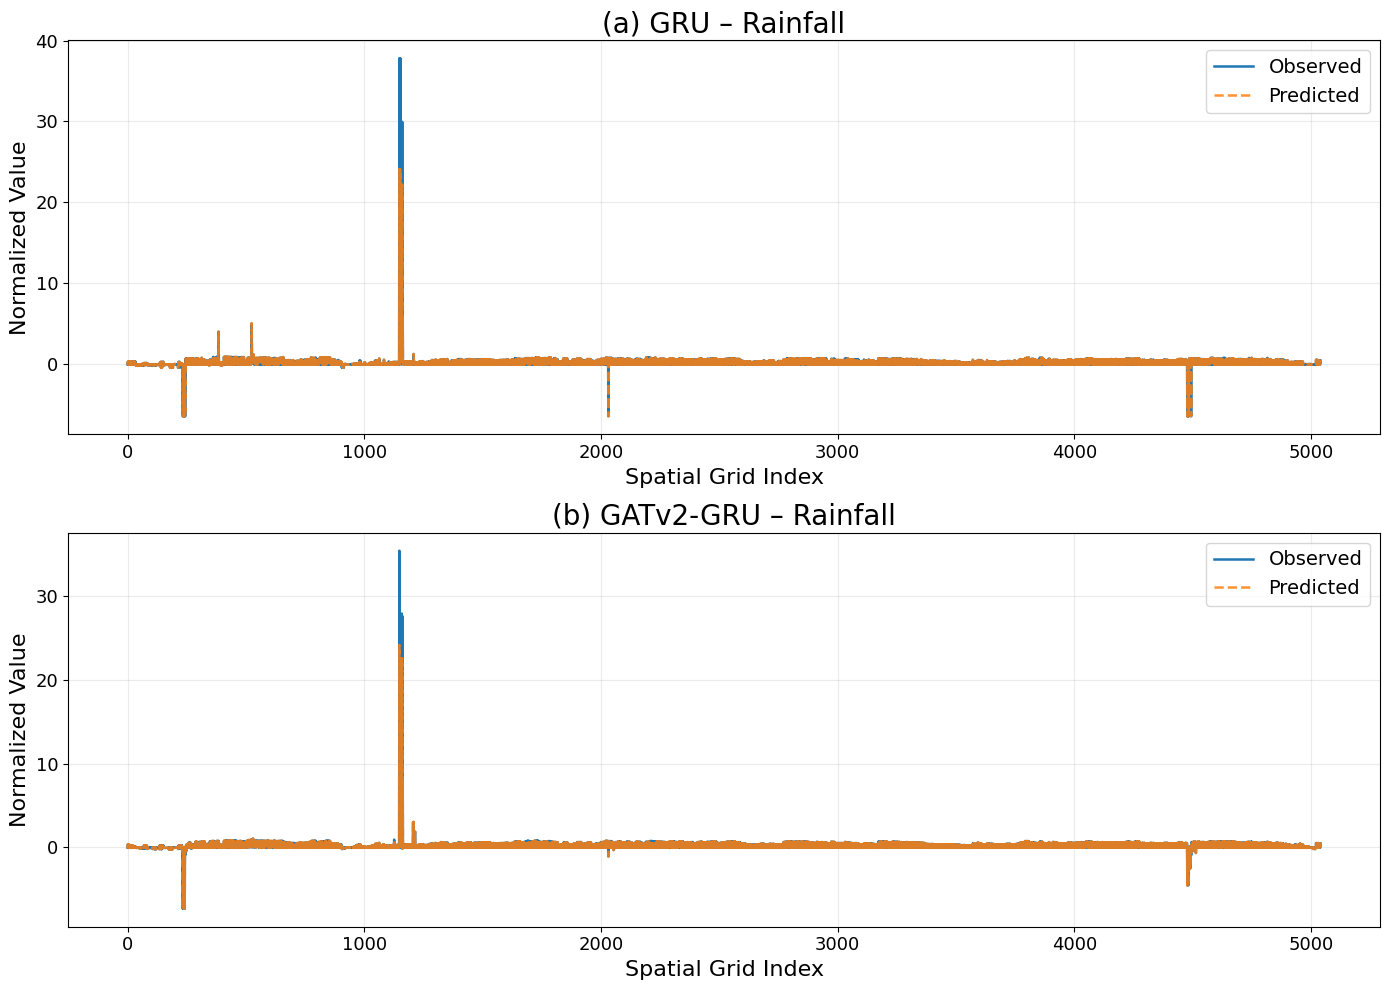


Figure 6 saved successfully.


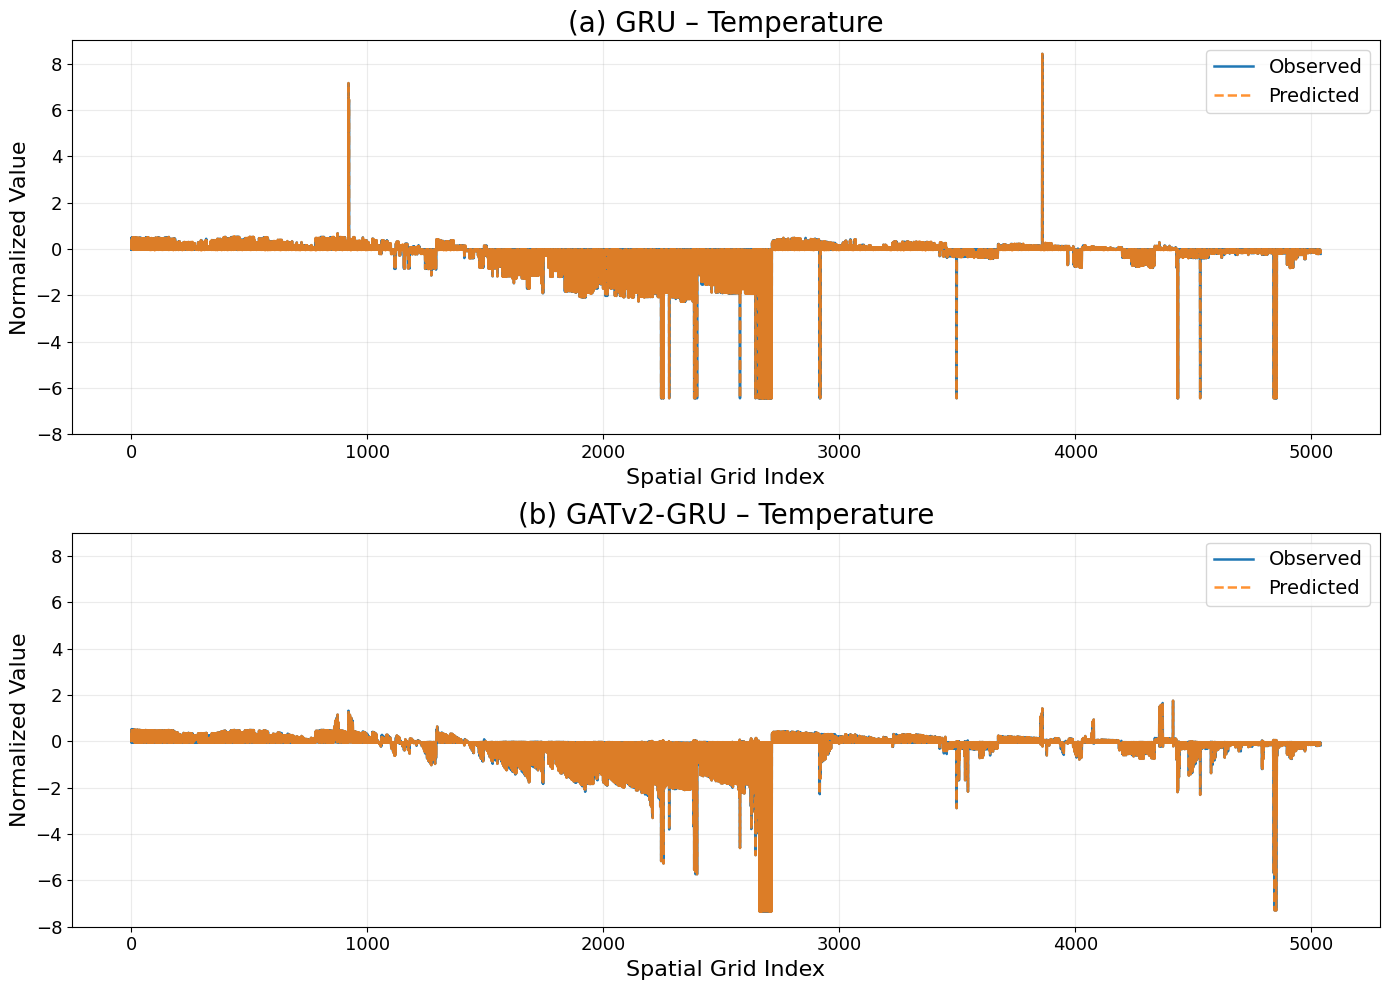


Figure 7 saved successfully.


In [7]:
# ============================================================
# FIGURE: OBSERVED VS PREDICTED COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# FINAL CONFIGURATION
# ============================================================

best_hidden_size = 128
best_epochs = 500

# ============================================================
# CREATE SEQUENCES
# ============================================================

X_raw_seq, y_raw_seq = create_sequences(
    X_raw,
    window_size
)

X_spatial_seq, y_spatial_seq = create_sequences(
    X_spatial,
    window_size
)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

split_raw = int(0.8 * len(X_raw_seq))

X_raw_train = X_raw_seq[:split_raw]
X_raw_test  = X_raw_seq[split_raw:]

y_raw_train = y_raw_seq[:split_raw]
y_raw_test  = y_raw_seq[split_raw:]

split_spatial = int(0.8 * len(X_spatial_seq))

X_spatial_train = X_spatial_seq[:split_spatial]
X_spatial_test  = X_spatial_seq[split_spatial:]

y_spatial_train = y_spatial_seq[:split_spatial]
y_spatial_test  = y_spatial_seq[split_spatial:]

# ============================================================
# TRAIN FINAL GRU (RAW)
# ============================================================

torch.manual_seed(42)

gru_model = GRUModel(
    X_raw.shape[1],
    best_hidden_size
).to(device)

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=learning_rate
)

criterion = torch.nn.MSELoss()

print("Training Final GRU (Raw)")

for epoch in range(best_epochs):

    gru_model.train()

    optimizer.zero_grad()

    pred = gru_model(X_raw_train)

    loss = criterion(pred, y_raw_train)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch+1}/{best_epochs} "
            f"| Loss: {loss.item():.6f}"
        )

# ============================================================
# TRAIN FINAL GATv2-GRU
# ============================================================

torch.manual_seed(42)

gatv2_gru_model = GRUModel(
    X_spatial.shape[1],
    best_hidden_size
).to(device)

optimizer = torch.optim.Adam(
    gatv2_gru_model.parameters(),
    lr=learning_rate
)

criterion = torch.nn.MSELoss()

print("\nTraining Final GATv2-GRU")

for epoch in range(best_epochs):

    gatv2_gru_model.train()

    optimizer.zero_grad()

    pred = gatv2_gru_model(X_spatial_train)

    loss = criterion(pred, y_spatial_train)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch+1}/{best_epochs} "
            f"| Loss: {loss.item():.6f}"
        )

# ============================================================
# EVALUATION
# ============================================================

gru_model.eval()
gatv2_gru_model.eval()

with torch.no_grad():

    gru_predictions = gru_model(X_raw_test)

    gatv2_gru_predictions = gatv2_gru_model(
        X_spatial_test
    )

# ============================================================
# CONVERT TO NUMPY
# ============================================================

gru_predictions = (
    gru_predictions.detach()
    .cpu()
    .numpy()
)

gru_targets = (
    y_raw_test.detach()
    .cpu()
    .numpy()
)

gatv2_gru_predictions = (
    gatv2_gru_predictions.detach()
    .cpu()
    .numpy()
)

gatv2_gru_targets = (
    y_spatial_test.detach()
    .cpu()
    .numpy()
)

# ============================================================
# SELECT TEST SAMPLE
# ============================================================

sample_idx = 0

# ============================================================
# SPLIT RAINFALL & TEMPERATURE
# ============================================================

# ---------------- GRU ----------------

gru_true = gru_targets[sample_idx]
gru_pred = gru_predictions[sample_idx]

gru_rain_true = gru_true[:num_nodes]
gru_temp_true = gru_true[num_nodes:]

gru_rain_pred = gru_pred[:num_nodes]
gru_temp_pred = gru_pred[num_nodes:]

# ---------------- GATv2-GRU ----------------

gat_true = gatv2_gru_targets[sample_idx]
gat_pred = gatv2_gru_predictions[sample_idx]

gat_rain_true = gat_true[:num_nodes]
gat_temp_true = gat_true[num_nodes:]

gat_rain_pred = gat_pred[:num_nodes]
gat_temp_pred = gat_pred[num_nodes:]

# ============================================================

# COMMON PLOT SETTINGS

# ============================================================

TITLE_SIZE = 20
LABEL_SIZE = 16
TICK_SIZE  = 13
LEGEND_SIZE = 14
LINE_WIDTH = 1.8

XTICKS = range(0, num_nodes + 1, 1000)

# ============================================================

# FIGURE 6: RAINFALL COMPARISON

# ============================================================

fig, axes = plt.subplots(
2,
1,
figsize=(14, 10)
)

# ------------------------------------------------------------

# (a) GRU – Rainfall

# ------------------------------------------------------------

axes[0].plot(
gru_rain_true,
label='Observed',
linewidth=LINE_WIDTH
)

axes[0].plot(
gru_rain_pred,
linestyle='--',
label='Predicted',
linewidth=LINE_WIDTH,
alpha=0.85
)

axes[0].set_title(
'(a) GRU – Rainfall',
fontsize=TITLE_SIZE
)

axes[0].set_xlabel(
'Spatial Grid Index',
fontsize=LABEL_SIZE
)

axes[0].set_ylabel(
'Normalized Value',
fontsize=LABEL_SIZE
)

axes[0].set_xticks(XTICKS)

axes[0].tick_params(axis='both', labelsize=TICK_SIZE)

axes[0].legend(fontsize=LEGEND_SIZE)

axes[0].grid(True, alpha=0.25)

# ------------------------------------------------------------

# (b) GATv2-GRU – Rainfall

# ------------------------------------------------------------

axes[1].plot(
gat_rain_true,
label='Observed',
linewidth=LINE_WIDTH
)

axes[1].plot(
gat_rain_pred,
linestyle='--',
label='Predicted',
linewidth=LINE_WIDTH,
alpha=0.85
)

axes[1].set_title(
'(b) GATv2-GRU – Rainfall',
fontsize=TITLE_SIZE
)

axes[1].set_xlabel(
'Spatial Grid Index',
fontsize=LABEL_SIZE
)

axes[1].set_ylabel(
'Normalized Value',
fontsize=LABEL_SIZE
)

axes[1].set_xticks(XTICKS)

axes[1].tick_params(axis='both', labelsize=TICK_SIZE)

axes[1].legend(fontsize=LEGEND_SIZE)

axes[1].grid(True, alpha=0.25)

# ------------------------------------------------------------

# FINAL LAYOUT

# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------

# SAVE FIGURE

# ------------------------------------------------------------

plt.savefig(
"/kaggle/working/Figure6_Rainfall_Comparison.png",
dpi=600,
bbox_inches='tight'
)

plt.show()

print("\nFigure 6 saved successfully.")

# ============================================================

# FIGURE 7: TEMPERATURE COMPARISON

# ============================================================

fig, axes = plt.subplots(
2,
1,
figsize=(14, 10)
)

# ------------------------------------------------------------

# (a) GRU – Temperature

# ------------------------------------------------------------

axes[0].plot(
gru_temp_true,
label='Observed',
linewidth=LINE_WIDTH
)

axes[0].plot(
gru_temp_pred,
linestyle='--',
label='Predicted',
linewidth=LINE_WIDTH,
alpha=0.85
)

axes[0].set_title(
'(a) GRU – Temperature',
fontsize=TITLE_SIZE
)

axes[0].set_xlabel(
'Spatial Grid Index',
fontsize=LABEL_SIZE
)

axes[0].set_ylabel(
'Normalized Value',
fontsize=LABEL_SIZE
)

axes[0].set_xticks(XTICKS)

axes[0].tick_params(axis='both', labelsize=TICK_SIZE)

axes[0].set_ylim(-8, 9)

axes[0].legend(fontsize=LEGEND_SIZE)

axes[0].grid(True, alpha=0.25)

# ------------------------------------------------------------

# (b) GATv2-GRU – Temperature

# ------------------------------------------------------------

axes[1].plot(
gat_temp_true,
label='Observed',
linewidth=LINE_WIDTH
)

axes[1].plot(
gat_temp_pred,
linestyle='--',
label='Predicted',
linewidth=LINE_WIDTH,
alpha=0.85
)

axes[1].set_title(
'(b) GATv2-GRU – Temperature',
fontsize=TITLE_SIZE
)

axes[1].set_xlabel(
'Spatial Grid Index',
fontsize=LABEL_SIZE
)

axes[1].set_ylabel(
'Normalized Value',
fontsize=LABEL_SIZE
)

axes[1].set_xticks(XTICKS)

axes[1].tick_params(axis='both', labelsize=TICK_SIZE)

axes[1].set_ylim(-8, 9)

axes[1].legend(fontsize=LEGEND_SIZE)

axes[1].grid(True, alpha=0.25)

# ------------------------------------------------------------

# FINAL LAYOUT

# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------

# SAVE FIGURE

# ------------------------------------------------------------

plt.savefig(
"/kaggle/working/Figure7_Temperature_Comparison.png",
dpi=600,
bbox_inches='tight'
)

plt.show()

print("\nFigure 7 saved successfully.")
